In [1]:
import numpy as np

from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, LogNorm

from tqdm.notebook import trange

%matplotlib widget

In [2]:
h = 4
r_gal = 26
r_sun = 8.5
v_sun = 220

sin = lambda degrees: np.sin(np.deg2rad(degrees))
cos = lambda degrees: np.cos(np.deg2rad(degrees))
tan = lambda degrees: np.tan(np.deg2rad(degrees))

def calc_R_min_max_1(l, b, h, r_gal, r_sun): # r_sun < r_gal < 2 r_sun
    l = l % 360
    if b == 0:
        b = 1e-10
    r_b = h / np.abs(tan(b))
    r_l = np.sqrt(r_sun**2 + r_b**2 - 2 * r_sun * r_b * cos(l))
    if r_b >= r_gal + r_sun: # 1
        if cos(l) >= 0:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_gal
        else:
            R_min = r_sun
            R_max = r_gal
    elif 2 * r_sun <= r_b < r_gal + r_sun: # 2
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= (r_sun - y_0) / r_b:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif 0 <= cos(l) < (r_sun - y_0) / r_b:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_gal
        else:
            R_min = r_sun
            R_max = r_gal
    elif np.sqrt(r_gal**2 - r_sun**2) <= r_b < 2 * r_sun: # 3
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif (r_sun - y_0) / r_b <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_gal
    elif r_sun <= r_b < np.sqrt(r_gal**2 - r_sun**2): # 4
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif (r_sun - y_0) / r_b <= cos(l) < 0:
            R_min = r_sun
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_gal
    elif r_gal - r_sun <= r_b < r_sun: # 5
        if cos(l) >= r_b / (2 * r_sun):
            R_min = r_l
            R_max = r_sun
        elif r_b / (2 * r_sun) <= cos(l) < r_b / r_sun:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif (r_sun - y_0) / r_b <= cos(l) < 0:
            R_min = r_sun
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_l
    else: # 6
        if cos(l) >= r_b / r_sun:
            R_min = r_l
            R_max = r_sun
        elif r_b / (2 * r_sun) <= cos(l) < r_b / r_sun:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_l
    return R_min, R_max

def calc_R_min_max_2(l, b, h, r_gal, r_sun): # 2 r_sun < r_gal < sqrt(5) r_sun
    l = l % 360
    if b == 0:
        b = 1e-10
    r_b = h / np.abs(tan(b))
    r_l = np.sqrt(r_sun**2 + r_b**2 - 2 * r_sun * r_b * cos(l))
    if r_b >= r_gal + r_sun: # 1
        if cos(l) >= 0:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_gal
        else:
            R_min = r_sun
            R_max = r_gal
    elif 2 * r_sun <= r_b < r_gal + r_sun: # 2
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= (r_sun - y_0) / r_b:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif 0 <= cos(l) < (r_sun - y_0) / r_b:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_gal
        else:
            R_min = r_sun
            R_max = r_gal
    elif np.sqrt(r_gal**2 - r_sun**2) <= r_b < 2 * r_sun: # 3
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif (r_sun - y_0) / r_b <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_gal
    elif r_gal - r_sun <= r_b < np.sqrt(r_gal**2 - r_sun**2): # 4
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif (r_sun - y_0) / r_b <= cos(l) < 0:
            R_min = r_sun
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_gal
    elif r_sun <= r_b < r_gal - r_sun: # 5
        if cos(l) >= r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_l
    else: # 6
        if cos(l) >= r_b / r_sun:
            R_min = r_l
            R_max = r_sun
        elif r_b / (2 * r_sun) <= cos(l) < r_b / r_sun:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_l
    return R_min, R_max

def calc_R_min_max_3(l, b, h, r_gal, r_sun): # sqrt(5) r_sun < r_gal < 3 r_sun
    l = l % 360
    if b == 0:
        b = 1e-10
    r_b = h / np.abs(tan(b))
    r_l = np.sqrt(r_sun**2 + r_b**2 - 2 * r_sun * r_b * cos(l))
    if r_b >= r_gal + r_sun: # 1
        if cos(l) >= 0:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_gal
        else:
            R_min = r_sun
            R_max = r_gal
    elif np.sqrt(r_gal**2 - r_sun**2) <= r_b < r_gal + r_sun: # 2
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= (r_sun - y_0) / r_b:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif 0 <= cos(l) < (r_sun - y_0) / r_b:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_gal
        else:
            R_min = r_sun
            R_max = r_gal
    elif 2 * r_sun <= r_b < np.sqrt(r_gal**2 - r_sun**2): # 3
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= 0:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif (r_sun - y_0) / r_b <= cos(l) < 0:
            R_min = r_sun
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_gal
    elif r_gal - r_sun <= r_b < 2 * r_sun: # 4
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif (r_sun - y_0) / r_b <= cos(l) < 0:
            R_min = r_sun
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_gal
    elif r_sun <= r_b < r_gal - r_sun: # 5
        if cos(l) >= r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_l
    else: # 6
        if cos(l) >= r_b / r_sun:
            R_min = r_l
            R_max = r_sun
        elif r_b / (2 * r_sun) <= cos(l) < r_b / r_sun:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_l
    return R_min, R_max

def calc_R_min_max_4(l, b, h, r_gal, r_sun): # r_gal >= 3 r_sun
    l = l % 360
    if b == 0:
        b = 1e-10
    r_b = h / np.abs(tan(b))
    r_l = np.sqrt(r_sun**2 + r_b**2 - 2 * r_sun * r_b * cos(l))
    if r_b >= r_gal + r_sun: # 1
        if cos(l) >= 0:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_gal
        else:
            R_min = r_sun
            R_max = r_gal
    elif np.sqrt(r_gal**2 - r_sun**2) <= r_b < r_gal + r_sun: # 2
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= (r_sun - y_0) / r_b:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif 0 <= cos(l) < (r_sun - y_0) / r_b:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_gal
        else:
            R_min = r_sun
            R_max = r_gal
    elif r_gal - r_sun <= r_b < np.sqrt(r_gal**2 - r_sun**2): # 3
        y_0 = (r_gal**2 + r_sun**2 - r_b**2) / (2 * r_sun)
        if cos(l) >= 0:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        elif (r_sun - y_0) / r_b <= cos(l) < 0:
            R_min = r_sun
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_gal
    elif 2 * r_sun <= r_b < r_gal - r_sun: # 4
        if cos(l) >= 0:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        else:
            R_min = r_sun
            R_max = r_l
    elif r_sun <= r_b < 2 * r_sun: # 5
        if cos(l) >= r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_l
    else: # 6
        if cos(l) >= r_b / r_sun:
            R_min = r_l
            R_max = r_sun
        elif r_b / (2 * r_sun) <= cos(l) < r_b / r_sun:
            R_min = r_sun * np.abs(sin(l))
            R_max = r_sun
        elif 0 <= cos(l) < r_b / (2 * r_sun):
            R_min = r_sun * np.abs(sin(l))
            R_max = r_l
        else:
            R_min = r_sun
            R_max = r_l
    return R_min, R_max


In [3]:
def v_rot_simple(r):
    v_rot = np.where(r > 0.5, 220, 440 * r)
    return v_rot

In [4]:
def v_rot_univ(r, a2=0.96, a3=1.62, r_sun=8.15):
    """
    Calculate the circular rotation speed (Vr) at a given galactocentric radius (r).

    Parameters:
        r (float): Galactocentric radius in kpc.
        a2 (float): r_opt/r_sun, where r_opt = 3.2 * r_scale_length encloses 83% of light
        a3 (float): 1.5 * (L/L*)^(1/5)
        r_sun (float): The distance from Sun to Galactic Center in kpc.

    Returns:
        Tr (float): Circular rotation speed at radius r in km/s.
    """
    # Calculate lambda = L/L*
    lambda_ = (a3 / 1.5) ** 5

    # Calculate r_opt
    r_opt = a2 * r_sun

    # Calculate normalized radius x
    x = r / r_opt

    # Calculate log10(lambda)
    log_lam = np.log10(lambda_)

    # Calculate term1
    term1 = 200.0 * lambda_**0.41

    # Calculate term2
    top = 0.75 * np.exp(-0.4 * lambda_)
    bot = 0.47 + 2.25 * lambda_**0.4
    term2 = np.sqrt(0.80 + 0.49 * log_lam + (top / bot))

    # Calculate term3
    top = 1.97 * x**1.22
    bot = (x**2 + 0.61) ** 1.43
    term3 = (0.72 + 0.44 * log_lam) * (top / bot)

    # Calculate term4
    top = x**2
    bot = x**2 + 2.25 * lambda_**0.4
    term4 = 1.6 * np.exp(-0.4 * lambda_) * (top / bot)

    # Calculate Vr (rotation speed)
    Vr = (term1 / term2) * np.sqrt(term3 + term4)  # km/s

    return Vr


In [5]:
def v_rot_linear(r):
    v_rot = 229 - 1.7 * r
    return v_rot

In [6]:
def v_rot_linear2(r):
    v_rot = np.where(r > 5, 229 - 1.7 * r, 44.1 * r)
    return v_rot

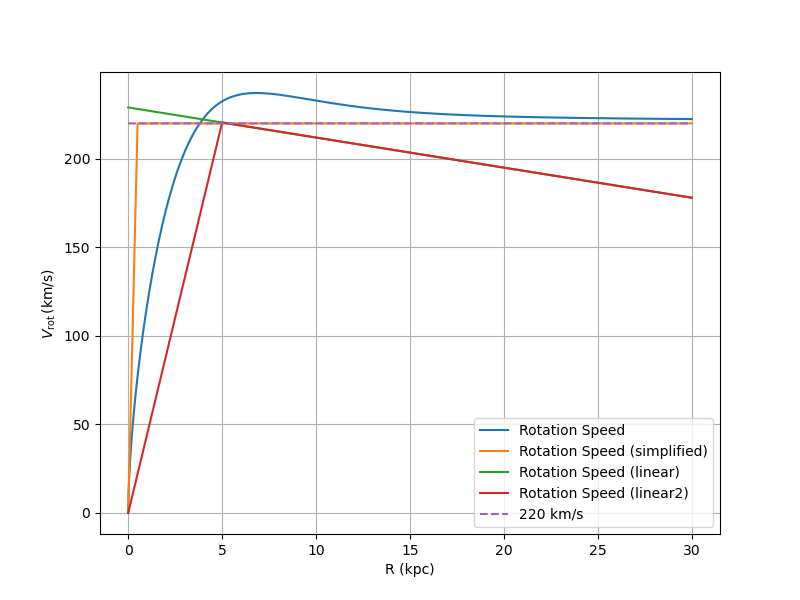

In [7]:
r = np.arange(0, 30, 0.01)
Vr = v_rot_univ(r)
Vr_simple = v_rot_simple(r)
Vr_linear = v_rot_linear(r)
Vr_linear2 = v_rot_linear2(r)
V_220 = np.ones_like(r) * 220

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(r, Vr, label="Rotation Speed")
plt.plot(r, Vr_simple, label="Rotation Speed (simplified)")
plt.plot(r, Vr_linear, label="Rotation Speed (linear)")
plt.plot(r, Vr_linear2, label="Rotation Speed (linear2)")
plt.plot(r, V_220, label="220 km/s", ls="--")
plt.xlabel("R (kpc)")
plt.ylabel(r"$V_{\mathrm{rot}}\,\mathrm{(km/s)}$")
plt.legend()
plt.grid()
plt.show()

In [8]:
def calc_v_max_min_simple(l, b, h, r_gal, r_sun=8.5, v_dev=0):
    if r_sun < r_gal < 2 * r_sun:
        R_min, R_max = calc_R_min_max_1(l, b, h, r_gal, r_sun)
    elif 2 * r_sun < r_gal < np.sqrt(5) * r_sun:
        R_min, R_max = calc_R_min_max_2(l, b, h, r_gal, r_sun)
    elif np.sqrt(5) * r_sun < r_gal < 3 * r_sun:
        R_min, R_max = calc_R_min_max_3(l, b, h, r_gal, r_sun)
    else:
        R_min, R_max = calc_R_min_max_4(l, b, h, r_gal, r_sun)
    v_1 = (v_rot_simple(R_min) * r_sun / R_min - v_sun) * sin(l) * cos(b)
    v_2 = (v_rot_simple(R_max) * r_sun / R_max - v_sun) * sin(l) * cos(b)
    v_max = np.max([v_1, v_2]) + v_dev
    v_min = np.min([v_1, v_2]) - v_dev
    return v_max, v_min


In [9]:
def calc_v_max_min_univ(l, b, h, r_gal, r_sun=8.5, n_sample=1000, v_dev=0):
    if r_sun < r_gal < 2 * r_sun:
        R_min, R_max = calc_R_min_max_1(l, b, h, r_gal, r_sun)
    elif 2 * r_sun < r_gal < np.sqrt(5) * r_sun:
        R_min, R_max = calc_R_min_max_2(l, b, h, r_gal, r_sun)
    elif np.sqrt(5) * r_sun < r_gal < 3 * r_sun:
        R_min, R_max = calc_R_min_max_3(l, b, h, r_gal, r_sun)
    else:
        R_min, R_max = calc_R_min_max_4(l, b, h, r_gal, r_sun)
    # R的范围和采样数
    if R_min == 0:
        R_min = 1e-10
    if R_max == 0:
        R_max = 1e-10
    R = np.linspace(R_min, R_max, n_sample+1)
    # 计算v
    v = (v_rot_univ(R) * r_sun / R - v_sun) * sin(l) * cos(b)
    # print(v)
    # 输出最小值和最大值
    v_max = np.max(v) + v_dev
    v_min = np.min(v) - v_dev
    return v_max, v_min


In [10]:
def calc_v_max_min_linear(l, b, h, r_gal, r_sun=8.5, n_sample=1000, v_dev=0):
    if r_sun < r_gal < 2 * r_sun:
        R_min, R_max = calc_R_min_max_1(l, b, h, r_gal, r_sun)
    elif 2 * r_sun < r_gal < np.sqrt(5) * r_sun:
        R_min, R_max = calc_R_min_max_2(l, b, h, r_gal, r_sun)
    elif np.sqrt(5) * r_sun < r_gal < 3 * r_sun:
        R_min, R_max = calc_R_min_max_3(l, b, h, r_gal, r_sun)
    else:
        R_min, R_max = calc_R_min_max_4(l, b, h, r_gal, r_sun)
    # R的范围和采样数
    if R_min == 0:
        R_min = 1e-10
    if R_max == 0:
        R_max = 1e-10
    R = np.linspace(R_min, R_max, n_sample+1)
    # 计算v
    v = (v_rot_linear(R) * r_sun / R - v_sun) * sin(l) * cos(b)
    # print(v)
    # 输出最小值和最大值
    v_max = np.max(v) + v_dev
    v_min = np.min(v) - v_dev
    return v_max, v_min


In [11]:
def calc_v_max_min_linear2(l, b, h, r_gal, r_sun=8.5, n_sample=1000, v_dev=0):
    if r_sun < r_gal < 2 * r_sun:
        R_min, R_max = calc_R_min_max_1(l, b, h, r_gal, r_sun)
    elif 2 * r_sun < r_gal < np.sqrt(5) * r_sun:
        R_min, R_max = calc_R_min_max_2(l, b, h, r_gal, r_sun)
    elif np.sqrt(5) * r_sun < r_gal < 3 * r_sun:
        R_min, R_max = calc_R_min_max_3(l, b, h, r_gal, r_sun)
    else:
        R_min, R_max = calc_R_min_max_4(l, b, h, r_gal, r_sun)
    # R的范围和采样数
    if R_min == 0:
        R_min = 1e-10
    if R_max == 0:
        R_max = 1e-10
    R = np.linspace(R_min, R_max, n_sample+1)
    # 计算v
    v = (v_rot_linear2(R) * r_sun / R - v_sun) * sin(l) * cos(b)
    # print(v)
    # 输出最小值和最大值
    v_max = np.max(v) + v_dev
    v_min = np.min(v) - v_dev
    return v_max, v_min


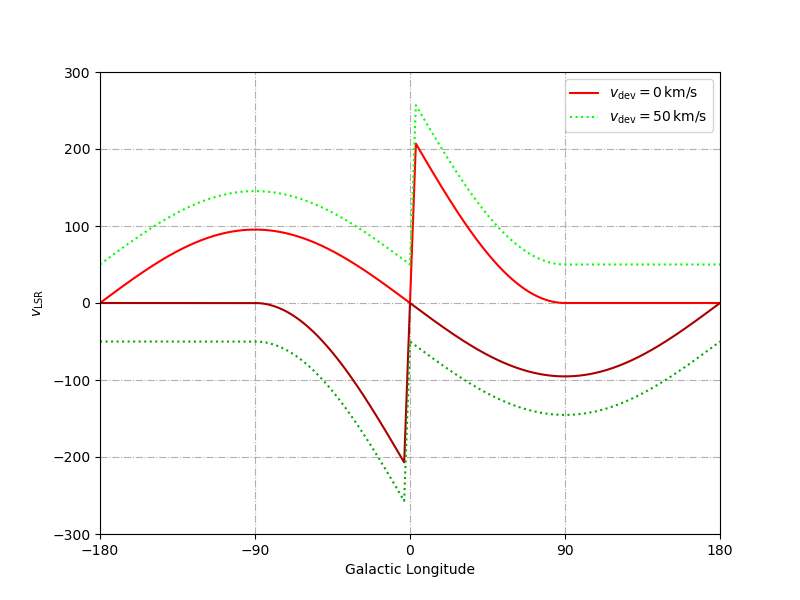

In [12]:
l_array = np.arange(-180,180.1,0.1)
v_max_arr1, v_min_arr1 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr2, v_min_arr2 = np.zeros_like(l_array), np.zeros_like(l_array)

for i in range(len(l_array)):
    v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_simple(l_array[i], b=0, h=5, r_gal=15)
    v_max_arr2[i], v_min_arr2[i] = calc_v_max_min_simple(l_array[i], b=0, h=5, r_gal=15, v_dev=50)

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$v_{\mathrm{dev}}=0\,\mathrm{km/s}$", color="#FF0000")
plt.plot(l_array, v_min_arr1, ls="-", color="#AA0000")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$v_{\mathrm{dev}}=50\,\mathrm{km/s}$", color="#00FF00")
plt.plot(l_array, v_min_arr2, ls=":", color="#00AA00")
#plt.gca().invert_xaxis()
plt.xticks(np.arange(-180,270,90))
plt.yticks(np.arange(-300,400,100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$v_{\mathrm{LSR}}$")
plt.xlim(-180,180)
plt.ylim(-300,300)
plt.grid(ls="-.")
plt.legend()
plt.show()

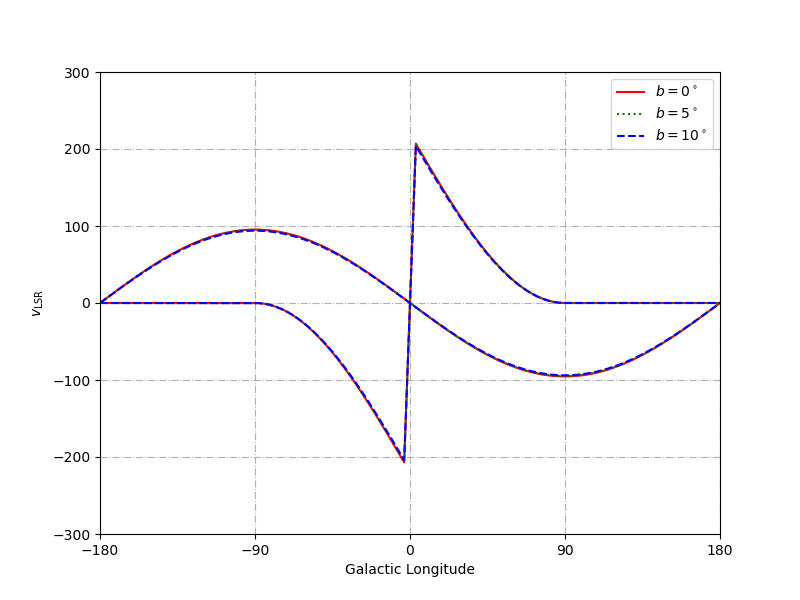

In [13]:
l_array = np.arange(-180,180.1,0.1)
v_max_arr1, v_min_arr1 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr2, v_min_arr2 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr3, v_min_arr3 = np.zeros_like(l_array), np.zeros_like(l_array)

for i in range(len(l_array)):
    v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_simple(l_array[i], b=0, h=5, r_gal=15)
    v_max_arr2[i], v_min_arr2[i] = calc_v_max_min_simple(l_array[i], b=5, h=5, r_gal=15)
    v_max_arr3[i], v_min_arr3[i] = calc_v_max_min_simple(l_array[i], b=10, h=5, r_gal=15)

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="r")
plt.plot(l_array, v_min_arr1, ls="-", color="r")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=5^\circ$", color="g")
plt.plot(l_array, v_min_arr2, ls=":", color="g")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=10^\circ$", color="b")
plt.plot(l_array, v_min_arr3, ls="--", color="b")
#plt.gca().invert_xaxis()
plt.xticks(np.arange(-180,270,90))
plt.yticks(np.arange(-300,400,100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$v_{\mathrm{LSR}}$")
plt.xlim(-180,180)
plt.ylim(-300,300)
plt.grid(ls="-.")
plt.legend()
plt.show()

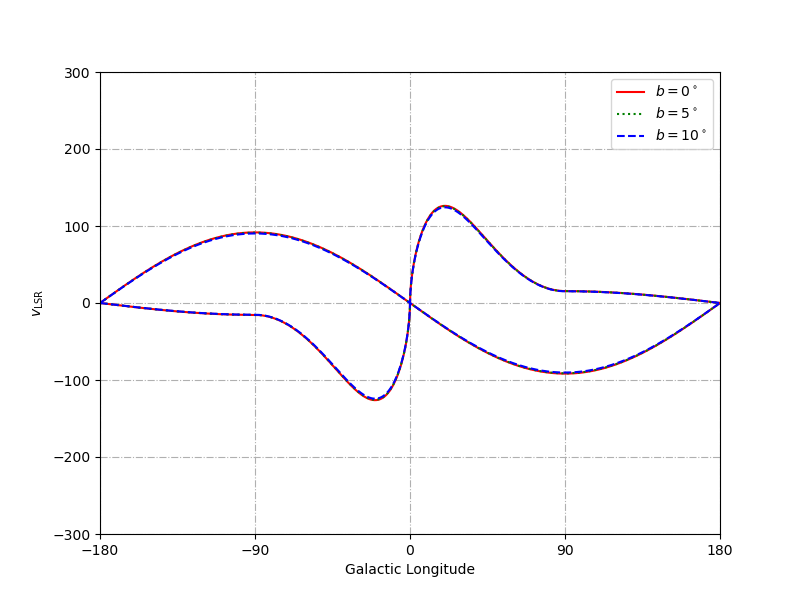

In [14]:
l_array = np.arange(-180,180.1,0.1)
v_max_arr1, v_min_arr1 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr2, v_min_arr2 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr3, v_min_arr3 = np.zeros_like(l_array), np.zeros_like(l_array)

for i in range(len(l_array)):
    v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_univ(l_array[i], b=0, h=5, r_gal=15)
    v_max_arr2[i], v_min_arr2[i] = calc_v_max_min_univ(l_array[i], b=5, h=5, r_gal=15)
    v_max_arr3[i], v_min_arr3[i] = calc_v_max_min_univ(l_array[i], b=10, h=5, r_gal=15)

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="r")
plt.plot(l_array, v_min_arr1, ls="-", color="r")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=5^\circ$", color="g")
plt.plot(l_array, v_min_arr2, ls=":", color="g")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=10^\circ$", color="b")
plt.plot(l_array, v_min_arr3, ls="--", color="b")
#plt.gca().invert_xaxis()
plt.xticks(np.arange(-180,270,90))
plt.yticks(np.arange(-300,400,100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$v_{\mathrm{LSR}}$")
plt.xlim(-180,180)
plt.ylim(-300,300)
plt.grid(ls="-.")
plt.legend()
plt.show()

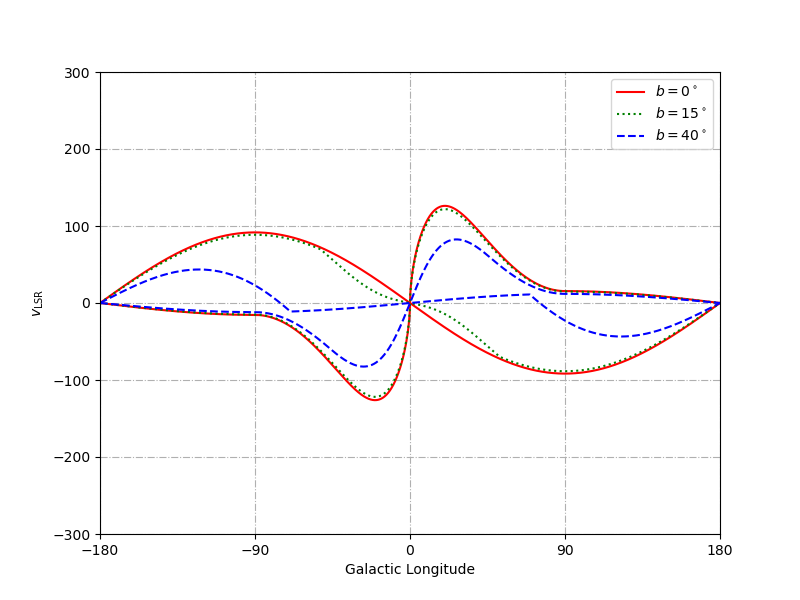

In [15]:
l_array = np.arange(-180,180.1,0.1)
v_max_arr1, v_min_arr1 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr2, v_min_arr2 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr3, v_min_arr3 = np.zeros_like(l_array), np.zeros_like(l_array)

for i in range(len(l_array)):
    v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_univ(l_array[i], b=0, h=5, r_gal=15)
    v_max_arr2[i], v_min_arr2[i] = calc_v_max_min_univ(l_array[i], b=15, h=5, r_gal=15)
    v_max_arr3[i], v_min_arr3[i] = calc_v_max_min_univ(l_array[i], b=40, h=5, r_gal=15)

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="r")
plt.plot(l_array, v_min_arr1, ls="-", color="r")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=15^\circ$", color="g")
plt.plot(l_array, v_min_arr2, ls=":", color="g")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=40^\circ$", color="b")
plt.plot(l_array, v_min_arr3, ls="--", color="b")
#plt.gca().invert_xaxis()
plt.xticks(np.arange(-180,270,90))
plt.yticks(np.arange(-300,400,100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$v_{\mathrm{LSR}}$")
plt.xlim(-180,180)
plt.ylim(-300,300)
plt.grid(ls="-.")
plt.legend()
plt.show()

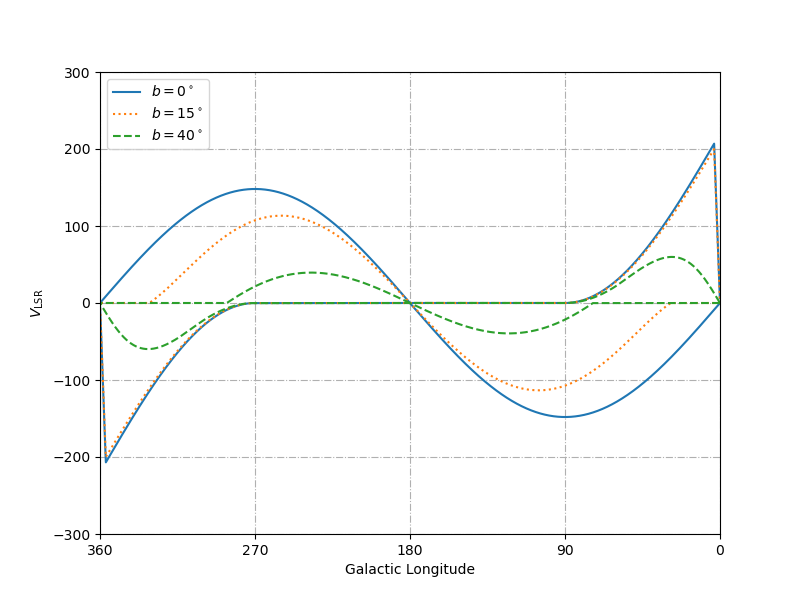

In [24]:
l_array = np.arange(0.1,360,0.1)
v_max_arr1, v_min_arr1 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr2, v_min_arr2 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr3, v_min_arr3 = np.zeros_like(l_array), np.zeros_like(l_array)

for i in range(len(l_array)):
    v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_simple(l_array[i], b=0, h=4, r_gal=26)
    v_max_arr2[i], v_min_arr2[i] = calc_v_max_min_simple(l_array[i], b=15, h=4, r_gal=26)
    v_max_arr3[i], v_min_arr3[i] = calc_v_max_min_simple(l_array[i], b=40, h=4, r_gal=26)

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="#1f77b4")
plt.plot(l_array, v_min_arr1, ls="-", color="#1f77b4")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=15^\circ$", color="#ff7f0e")
plt.plot(l_array, v_min_arr2, ls=":", color="#ff7f0e")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=40^\circ$", color="#2ca02c")
plt.plot(l_array, v_min_arr3, ls="--", color="#2ca02c")

plt.xticks(np.arange(0,450,90))
plt.yticks(np.arange(-300,400,100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$V_{\mathrm{LSR}}$")
plt.xlim(0,360)
plt.ylim(-300,300)
plt.grid(ls="-.")
plt.legend(loc='upper left')
plt.gca().invert_xaxis()
plt.savefig("Galaxy_Rotation_Model.png", dpi=300)
plt.show()

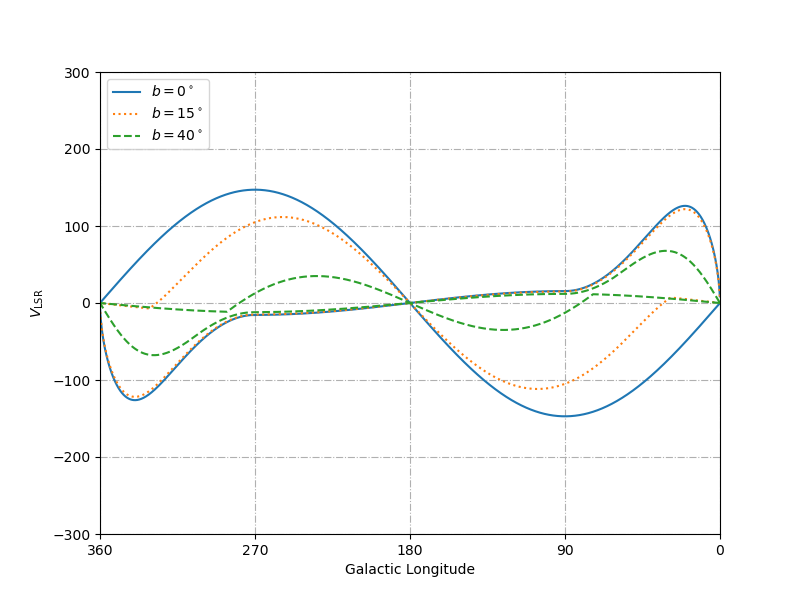

In [17]:
l_array = np.arange(0.1,360,0.1)
v_max_arr1, v_min_arr1 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr2, v_min_arr2 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr3, v_min_arr3 = np.zeros_like(l_array), np.zeros_like(l_array)

for i in range(len(l_array)):
    v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_univ(l_array[i], b=0, h=4, r_gal=26)
    v_max_arr2[i], v_min_arr2[i] = calc_v_max_min_univ(l_array[i], b=15, h=4, r_gal=26)
    v_max_arr3[i], v_min_arr3[i] = calc_v_max_min_univ(l_array[i], b=40, h=4, r_gal=26)

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(l_array, v_max_arr1, ls="-", label=r"$b=0^\circ$", color="#1f77b4")
plt.plot(l_array, v_min_arr1, ls="-", color="#1f77b4")
plt.plot(l_array, v_max_arr2, ls=":", label=r"$b=15^\circ$", color="#ff7f0e")
plt.plot(l_array, v_min_arr2, ls=":", color="#ff7f0e")
plt.plot(l_array, v_max_arr3, ls="--", label=r"$b=40^\circ$", color="#2ca02c")
plt.plot(l_array, v_min_arr3, ls="--", color="#2ca02c")

plt.xticks(np.arange(0,450,90))
plt.yticks(np.arange(-300,400,100))
plt.xlabel("Galactic Longitude")
plt.ylabel(r"$V_{\mathrm{LSR}}$")
plt.xlim(0,360)
plt.ylim(-300,300)
plt.grid(ls="-.")
plt.legend(loc='upper left')
plt.gca().invert_xaxis()
plt.savefig("Galaxy_Rotation_Model.png", dpi=300)
plt.show()

In [28]:
l = 231
b = 21.1
calc_v_max_min_univ(l, b, h=5, r_gal=20, v_dev=0)

(np.float64(88.55113484437311), np.float64(-11.221647067381626))

In [18]:
from astropy.io import fits
from astropy.wcs import WCS

hdul = fits.open("../HI4PI_Galatic_LV.fits")
header = hdul[0].header
lvdiagram = hdul[0].data

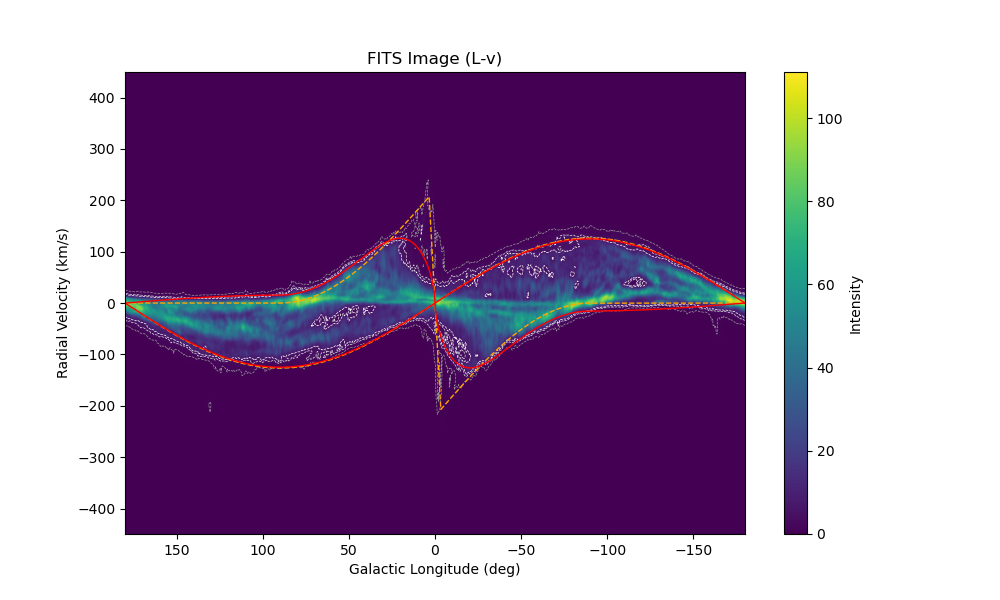

In [ ]:
filename = "../HI4PI_Galatic_LV.fits"

# 打开FITS文件
with fits.open(filename) as hdul:
    data = hdul[0].data
    header = hdul[0].header

# 构建WCS对象
wcs = WCS(header)

ny, nx = data.shape

# 画图

# 只用白色部分：用colormap的截取
cmap = plt.get_cmap('Greys_r')
white_cmap = mpl.colors.LinearSegmentedColormap.from_list('white_greys', cmap(np.linspace(0.5, 1.0, 256)))

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    data,
    origin='lower',
    aspect='auto',
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],            # l_min
        wcs.pixel_to_world_values(nx-1, 0)[0],         # l_max
        wcs.pixel_to_world_values(0, 0)[1]/1000,            # v_min
        wcs.pixel_to_world_values(0, ny-1)[1]/1000          # v_max
    ],
    norm=PowerNorm(gamma=1),  # 使用对数归一化
    cmap='viridis'  # 使用viridis色图
)
ax.contour(
    data,
    origin='lower',
    levels=np.arange(1, 10, 3),
    cmap=white_cmap,
    linewidths=0.5,
    linestyles='dashed',
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],            # l_min
        wcs.pixel_to_world_values(nx-1, 0)[0],         # l_max
        wcs.pixel_to_world_values(0, 0)[1]/1000,            # v_min
        wcs.pixel_to_world_values(0, ny-1)[1]/1000          # v_max
    ],)

ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Radial Velocity (km/s)')
plt.colorbar(im, ax=ax, label='Intensity')
plt.title('FITS Image (L-v)')

# 画L-V图
l_array = np.arange(-179.9,180,0.1)
v_max_arr1, v_min_arr1 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr2, v_min_arr2 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr3, v_min_arr3 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr4, v_min_arr4 = np.zeros_like(l_array), np.zeros_like(l_array)

for i in range(len(l_array)):
    v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_simple(l_array[i], b=0, h=5, r_gal=20)
ax.plot(l_array, v_max_arr1, color='orange', ls="--", linewidth=1)
ax.plot(l_array, v_min_arr1, color='orange', ls="--", linewidth=1)

for i in range(len(l_array)):
    v_max_arr2[i], v_min_arr2[i] = calc_v_max_min_univ(l_array[i], b=0, h=5, r_gal=20)
ax.plot(l_array, v_max_arr2, color='red', linewidth=1)
ax.plot(l_array, v_min_arr2, color='red', linewidth=1)
'''
for i in range(len(l_array)):
    v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_linear(l_array[i], b=0, h=5, r_gal=20)
ax.plot(l_array, v_max_arr1, color='green', ls="--", linewidth=1)
ax.plot(l_array, v_min_arr1, color='green', ls="--", linewidth=1)

for i in range(len(l_array)):
    v_max_arr2[i], v_min_arr2[i] = calc_v_max_min_linear2(l_array[i], b=0, h=5, r_gal=20)
ax.plot(l_array, v_max_arr2, color='cyan', linewidth=1)
ax.plot(l_array, v_min_arr2, color='cyan', linewidth=1)
'''
plt.show()

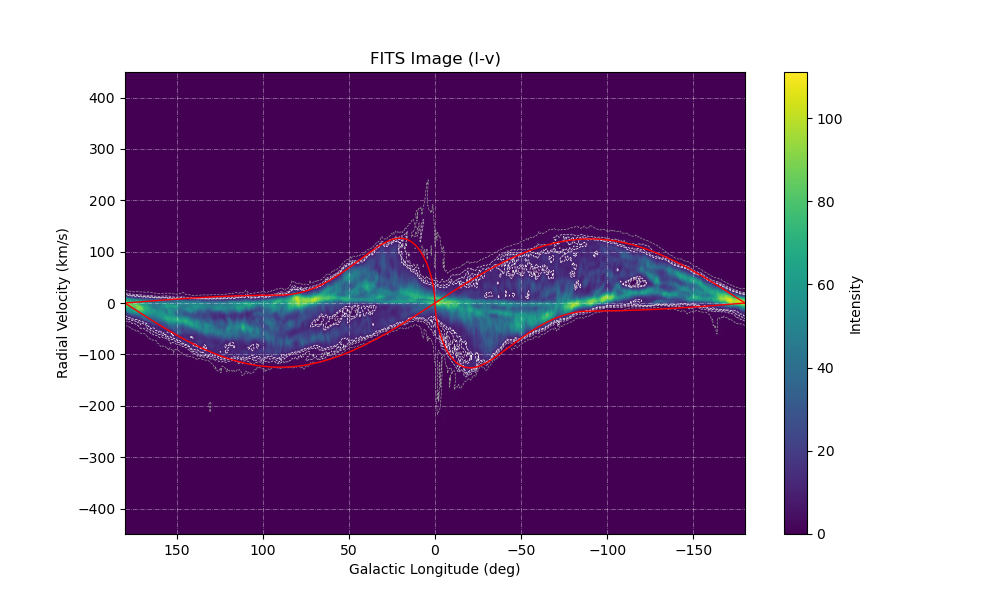

In [23]:
filename = "../HI4PI_Galatic_LV.fits"

# 打开FITS文件
with fits.open(filename) as hdul:
    data = hdul[0].data
    header = hdul[0].header

# 构建WCS对象
wcs = WCS(header)

ny, nx = data.shape

# 画图

# 只用白色部分：用colormap的截取
cmap = plt.get_cmap('Greys_r')
white_cmap = mpl.colors.LinearSegmentedColormap.from_list('white_greys', cmap(np.linspace(0.5, 1.0, 256)))

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(
    data,
    origin='lower',
    aspect='auto',
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],            # l_min
        wcs.pixel_to_world_values(nx-1, 0)[0],         # l_max
        wcs.pixel_to_world_values(0, 0)[1]/1000,            # v_min
        wcs.pixel_to_world_values(0, ny-1)[1]/1000          # v_max
    ],
    norm=PowerNorm(gamma=1),  # 使用对数归一化
    cmap='viridis'  # 使用viridis色图
)
ax.contour(
    data,
    origin='lower',
    levels=np.arange(1, 10, 2.5),
    cmap=white_cmap,
    linewidths=0.5,
    linestyles='dashed',
    extent=[
        wcs.pixel_to_world_values(0, 0)[0],            # l_min
        wcs.pixel_to_world_values(nx-1, 0)[0],         # l_max
        wcs.pixel_to_world_values(0, 0)[1]/1000,            # v_min
        wcs.pixel_to_world_values(0, ny-1)[1]/1000          # v_max
    ],)

ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Radial Velocity (km/s)')
plt.colorbar(im, ax=ax, label='Intensity')
plt.title('FITS Image (l-v)')

# 画L-V图
l_array = np.arange(-179.9,180,0.1)
v_max_arr1, v_min_arr1 = np.zeros_like(l_array), np.zeros_like(l_array)
v_max_arr2, v_min_arr2 = np.zeros_like(l_array), np.zeros_like(l_array)

# for i in range(len(l_array)):
#     v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_univ(l_array[i], b=0, h=5, r_gal=15)
# ax.plot(l_array, v_max_arr1, color='yellow', ls="--", linewidth=1)
# ax.plot(l_array, v_min_arr1, color='yellow', ls="--", linewidth=1)
#
# for i in range(len(l_array)):
#     v_max_arr1[i], v_min_arr1[i] = calc_v_max_min_univ(l_array[i], b=0, h=5, r_gal=25)
# ax.plot(l_array, v_max_arr1, color='orange', ls="--", linewidth=1)
# ax.plot(l_array, v_min_arr1, color='orange', ls="--", linewidth=1)

for i in range(len(l_array)):
    v_max_arr2[i], v_min_arr2[i] = calc_v_max_min_univ(l_array[i], b=0, h=5, r_gal=20)
ax.plot(l_array, v_max_arr2, color='red', linewidth=1)
ax.plot(l_array, v_min_arr2, color='red', linewidth=1)

ax.grid(ls="-.", color="white", alpha=0.5, linewidth=0.5)

plt.savefig("Galaxy_Rotation_Model_CRAFTS_HI.png", dpi=300)
plt.show()

In [21]:
l = np.arange(0, 360, 0.1)
b = np.arange(-90, 90.1, 0.1)

# 生成网格，每个像素的值为v_max或者v_min
v_max_arr, v_min_arr = np.meshgrid(l, b, indexing="ij")

In [22]:
for i in trange(len(l)):
    for j in range(len(b)):
        v_max_arr[i,j], v_min_arr[i,j] = calc_v_max_min_univ(l[i], b[j], h=5, r_gal=20, v_dev=0)

  0%|          | 0/3600 [00:00<?, ?it/s]

In [23]:
v_max_arr = v_max_arr.T  # 转置以匹配原始网格
v_min_arr = v_min_arr.T  # 转置以匹配原始网格

In [24]:
# 创建WCS头信息，NAXIS=3
hdr = fits.Header()
hdr['NAXIS'] = 2
hdr['NAXIS1'] = v_max_arr.shape[1]  # 3601 (l)
hdr['NAXIS2'] = v_max_arr.shape[0]  # 1801 (b)

# WCS信息
hdr['CTYPE1'] = 'GLON'
hdr['CRVAL1'] = 0.0
hdr['CRPIX1'] = 1.0
hdr['CDELT1'] = 0.1

hdr['CTYPE2'] = 'GLAT'
hdr['CRVAL2'] = -90.0
hdr['CRPIX2'] = 1.0
hdr['CDELT2'] = 0.1

hdr['BUNIT'] = 'km/s'
hdr


NAXIS   =                    2                                                  
NAXIS1  =                 3600                                                  
NAXIS2  =                 1801                                                  
CTYPE1  = 'GLON    '                                                            
CRVAL1  =                  0.0                                                  
CRPIX1  =                  1.0                                                  
CDELT1  =                  0.1                                                  
CTYPE2  = 'GLAT    '                                                            
CRVAL2  =                -90.0                                                  
CRPIX2  =                  1.0                                                  
CDELT2  =                  0.1                                                  
BUNIT   = 'km/s    '                                                            

In [25]:
hdu1 = fits.PrimaryHDU(v_max_arr, header=hdr)
hdu1.writeto("galaxy_rotation_model_+.fits", overwrite=True)
hdu2 = fits.PrimaryHDU(v_min_arr, header=hdr)
hdu2.writeto("galaxy_rotation_model_-.fits", overwrite=True)

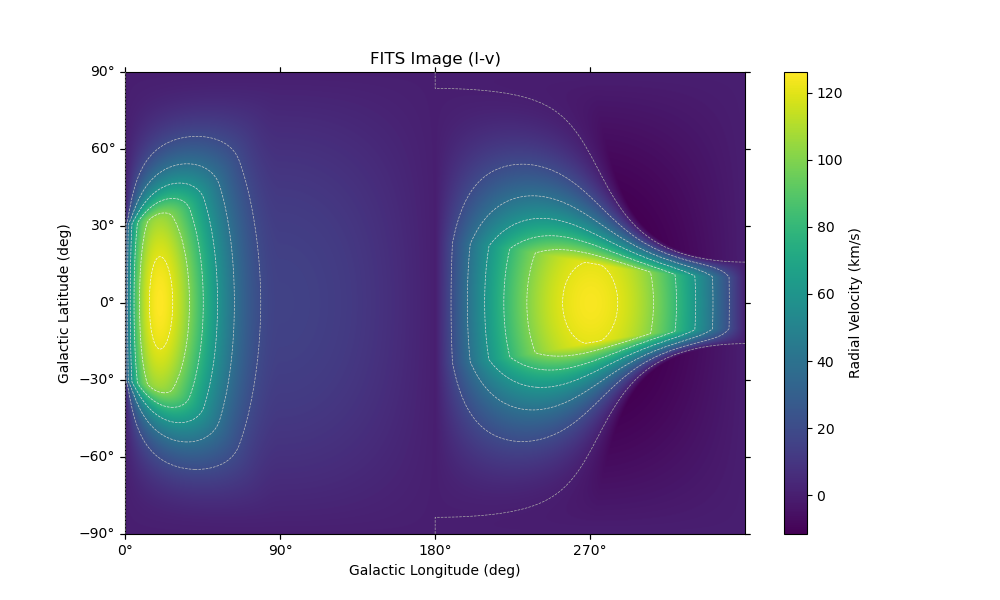

In [29]:
filename1 = "galaxy_rotation_model_+.fits"

# 打开FITS文件
with fits.open(filename1) as hdul:
    data1 = hdul[0].data
    header1 = hdul[0].header

wcs1 = WCS(header1)

# 画图
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': wcs2})
im = ax.imshow(
    data1,
    origin='lower',
    aspect='auto',
    norm=PowerNorm(gamma=1),  # 使用对数归一化
    cmap='viridis'  # 使用viridis色图
)
ax.contour(
    data1,
    origin='lower',
    cmap=white_cmap,
    linewidths=0.5,
    linestyles='dashed'
    )

ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Galactic Latitude (deg)')
plt.colorbar(im, ax=ax, label='Radial Velocity (km/s)')
plt.title('FITS Image (l-v)')

plt.show()

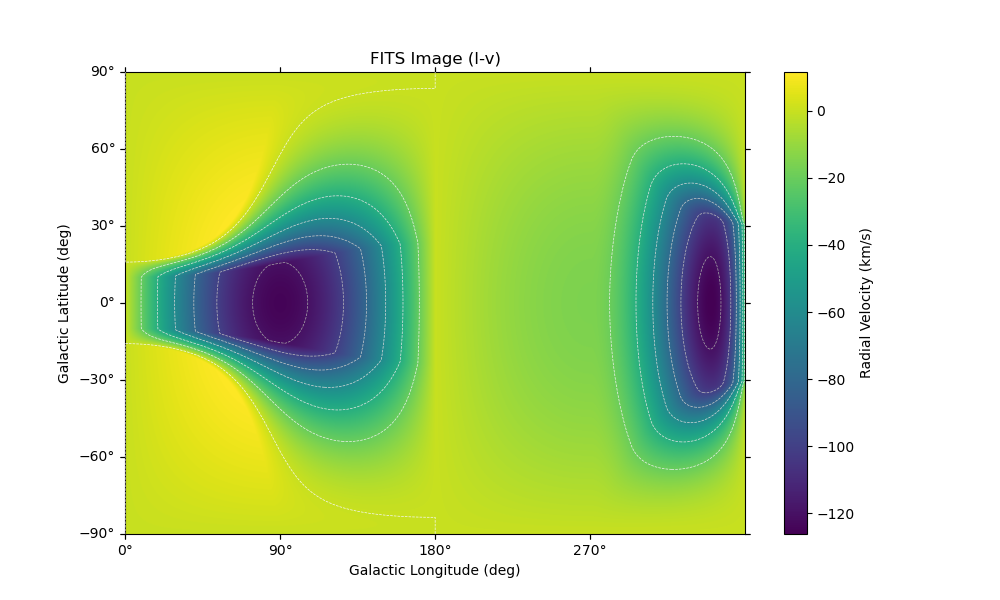

In [30]:
filename2 = "galaxy_rotation_model_-.fits"

# 打开FITS文件
with fits.open(filename2) as hdul:
    data2 = hdul[0].data
    header2 = hdul[0].header

wcs2 = WCS(header2)

# 画图
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': wcs2})
im = ax.imshow(
    data2,
    origin='lower',
    aspect='auto',
    norm=PowerNorm(gamma=1),  # 使用对数归一化
    cmap='viridis'  # 使用viridis色图
)
ax.contour(
    data2,
    origin='lower',
    cmap=white_cmap,
    linewidths=0.5,
    linestyles='dashed'
    )

ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Galactic Latitude (deg)')
plt.colorbar(im, ax=ax, label='Radial Velocity (km/s)')
plt.title('FITS Image (l-v)')

plt.show()